<a href="https://colab.research.google.com/github/nitka975/MachinelLearning/blob/main/%D0%9A%D0%BB%D0%B0%D1%81%D0%B8%D1%84%D1%96%D0%BA%D0%B0%D1%86%D1%96%D1%8F_%D0%B7%D0%BE%D0%B1%D1%80%D0%B0%D0%B6%D0%B5%D0%BD%D1%8C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import  matplotlib.pyplot as plt
import numpy as np
import cv2
from PIL import Image

In [2]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

In [3]:
print(X_test)
print(y_test)

[[[[158 112  49]
   [159 111  47]
   [165 116  51]
   ...
   [137  95  36]
   [126  91  36]
   [116  85  33]]

  [[152 112  51]
   [151 110  40]
   [159 114  45]
   ...
   [136  95  31]
   [125  91  32]
   [119  88  34]]

  [[151 110  47]
   [151 109  33]
   [158 111  36]
   ...
   [139  98  34]
   [130  95  34]
   [120  89  33]]

  ...

  [[ 68 124 177]
   [ 42 100 148]
   [ 31  88 137]
   ...
   [ 38  97 146]
   [ 13  64 108]
   [ 40  85 127]]

  [[ 61 116 168]
   [ 49 102 148]
   [ 35  85 132]
   ...
   [ 26  82 130]
   [ 29  82 126]
   [ 20  64 107]]

  [[ 54 107 160]
   [ 56 105 149]
   [ 45  89 132]
   ...
   [ 24  77 124]
   [ 34  84 129]
   [ 21  67 110]]]


 [[[235 235 235]
   [231 231 231]
   [232 232 232]
   ...
   [233 233 233]
   [233 233 233]
   [232 232 232]]

  [[238 238 238]
   [235 235 235]
   [235 235 235]
   ...
   [236 236 236]
   [236 236 236]
   [235 235 235]]

  [[237 237 237]
   [234 234 234]
   [234 234 234]
   ...
   [235 235 235]
   [235 235 235]
   [234 234

In [4]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [5]:
# Список назв класів українською мовою
class_name = ['літак', 'автомобіль', 'птах', 'кіт', 'олень', 'собака', 'жаба', 'кінь', 'корабель', 'вантажівка']

In [6]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3 )),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),

    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']

)

In [8]:
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.4501 - loss: 1.5049 - val_accuracy: 0.5384 - val_loss: 1.2920
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5896 - loss: 1.1618 - val_accuracy: 0.6212 - val_loss: 1.0738
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6408 - loss: 1.0165 - val_accuracy: 0.6326 - val_loss: 1.0306
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6756 - loss: 0.9258 - val_accuracy: 0.6720 - val_loss: 0.9437
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7043 - loss: 0.8453 - val_accuracy: 0.6864 - val_loss: 0.9032
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7233 - loss: 0.7911 - val_accuracy: 0.6863 - val_loss: 0.8963
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7426 - loss: 0.7406 - val_accuracy: 0.6884 - val_loss: 0.8917
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7533 - loss: 0.7011 -

#6. Оцінка точності моделі на тестових даних

In [9]:
loss, acc = model.evaluate(X_test, y_test)
print(f"\nТочність на тестовому наборі: {acc:.2f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7055 - loss: 0.8894

Точність на тестовому наборі: 0.71


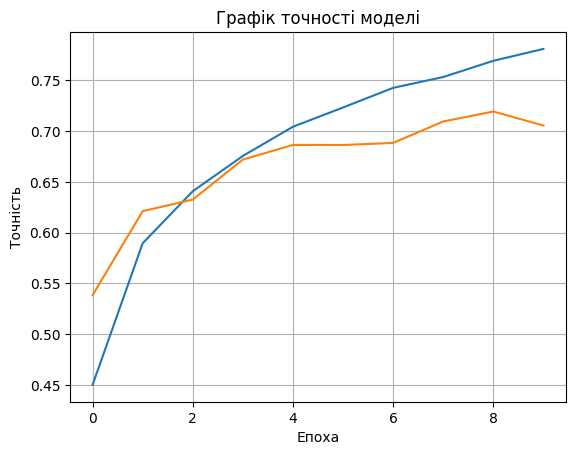

In [10]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel("Епоха")
plt.ylabel("Точність")
plt.title("Графік точності моделі")
plt.grid(True)
plt.show()

In [11]:
def load_and_prepare_image(img):
  image = Image.open(img).convert("RGB")
  image = image.resize((32, 32))
  image_array = np.array(image) / 255.0
  image_array = np.expand_dims(image_array, axis=0)

  return image_array

In [12]:
custom_image_path = 'Image.jpg'  #@param {type:"string"}

In [13]:
import os

if os.path.exists(custom_image_path):
  try:
    prepared_img = load_and_prepare_image(custom_image_path)
    prediction = model.predict(prepared_img)
    # print(prediction)
    predicted_class = np.argmax(prediction)
    confidence = np.max(prediction)

    print(f"Pred: {predicted_class} ({class_name[predicted_class]}) - on {confidence * 100:.2f}%")
  except Exception as e:
    print(f"Error: {e}")
else:
  print(f"Not found file {custom_image_path}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 589ms/step
Pred: 4 (олень) - on 60.44%


In [14]:
from google.colab import files

print("Upload file (JPG or PNG):")
uploaded = files.upload()

Upload file (JPG or PNG):


Saving Image.jpg to Image (1).jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Pred: 4 (олень) - on 60.44%


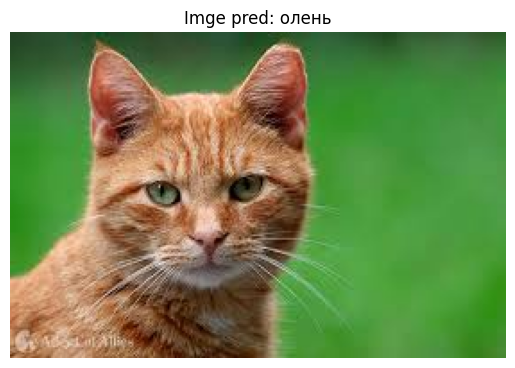

In [15]:
for f in uploaded.keys():
  img = f
  prepared_img = load_and_prepare_image(img)
  prediction = model.predict(prepared_img)
  # print(prediction)
  predicted_class = np.argmax(prediction)
  confidence = np.max(prediction)

  print(f"Pred: {predicted_class} ({class_name[predicted_class]}) - on {confidence * 100:.2f}%")

  img = Image.open(img)
  plt.imshow(img)
  plt.axis('off')
  plt.title(f"Imge pred: {class_name[predicted_class]}")
  plt.show()

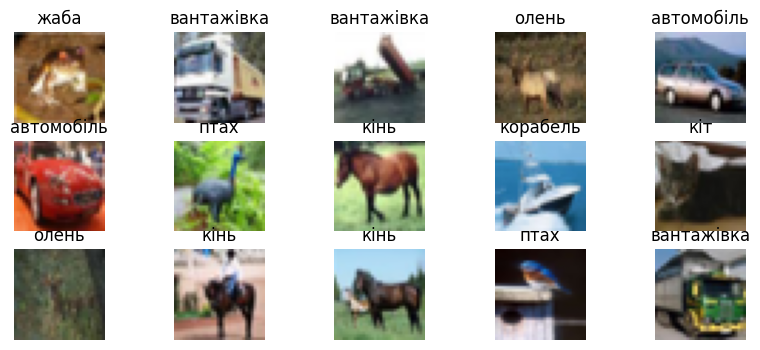

In [16]:
# import ..
# (X_train, y_train), (X_test, y_test) = ..
# class_name = ..

plt.figure(figsize=(10, 4))

for i in range(15):
  plt.subplot(3, 5, i + 1)
  plt.imshow(X_train[i])
  plt.title(class_name[y_train[i][0]] )
  plt.axis('off')
plt.show()